#### Three Principles: 
- Be **Reachable** within Workspace
- Be **Stable** under Gravity (*DISREGARD*)
- Be **Collision-Free**

#### Hypothesis: 
- Constant curvature
- All happen in 2D plane
- One gripper is "Always Rigid"

#### Decisions: 
- Hierarchy does not matter, but topology does

#### TODO: 
- [ ] A reachablility check function
- [ ] Visualization for the robots

02/17/2025 Draw the end trajectory when a segment bends with constant curvature

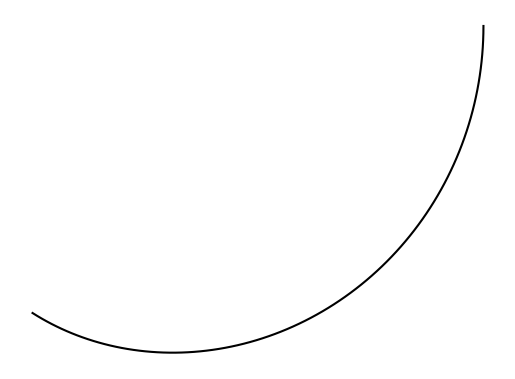

In [1]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0.0001, np.pi, 100)
l = 1       # Arc Length

x = l / theta * np.sin(theta)
y = l / theta * (np.cos(theta) - 1)

plt.plot(x, y, 'k-')
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()

02/20/2025 Test module and grasp

In [2]:
import sys
sys.path.append('..')

from Module import Module
m1 = Module()
m2 = Module()
m3 = Module()
# Use m1's tail to catch m2's head
print(m1.catch(m2, 0, 1))
# Use m3's head to catch m2's tail
print(m3.catch(m2, 1, 0))
# Use m2's head to catch m2's tail
print(m2.catch(m2, 1, 0))

True
True
False


02/20/2025 PCG for MRC

In [1]:
import sys
sys.path.append('..')

from MRC import MRC

MRC.Initiate(5)
print(MRC.get_simplest_configuration())

M0 tail holds M1 head
M2 tail holds M3 head


Module Robot Configuration Basic Data: 
w: 2; v: 2; n: 3; Gripper state: [ 4 -1 -2 -1  0  7 11  5 -2 -1 -1  6]
-----------------------------------------------------------------
Module to grippers are: [[4, -1, 3, 7, 6, 9, -1], [0, 1, -1, 5, 11, -1, 10]]
Grippers belong to module: [0, 1, -1, 2, 0, 3, 4, 3, -1, 5, 6, 4]
Grippers' head-tail conditions are: [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1]
-----------------------------------------------------------------
Edges in the graph: [(0, 1, 0), (0, -2, 0), (1, -4, 0), (1, 2, 0), (2, 3, 0), (3, -10, 0), (3, -11, 0)]
Module Cycles are: []
Grip Cycles are: []
Real Cycles are: []
-----------------------------------------------------------------
Module Loops are: []
Module Directions are: []
Grasp Loops are: []
Grasp Directions are: []
-----------------------------------------------------------------
Module Polarities are: [0, 0, 0, 0, 0, 0, 0]
Loop Polarities are: []
Grip Polarities are: [0, 1, 0, -1]
Modules for w-grips are: {1: [2, 0, 3], 3: [5, 

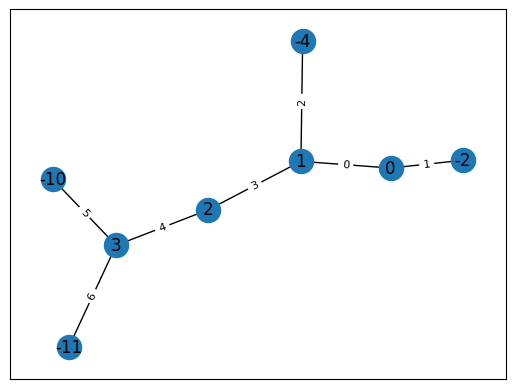

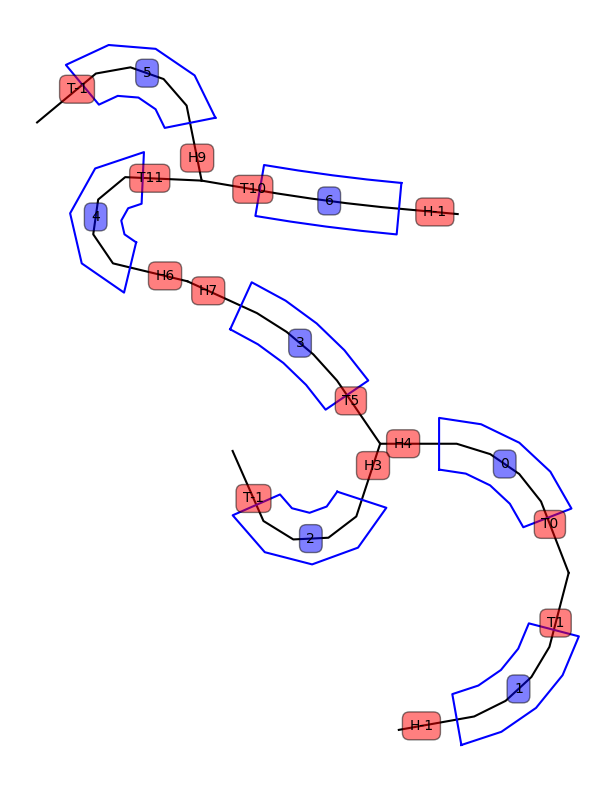

In [3]:
import sys
sys.path.append('..')

from MRC import MRC

MRC.Initiate(7)
mrc = MRC.get_random_configuration(seed=None, is_print=True)
# mrc = MRC.get_random_configuration(seed=0, is_print=True, w = 0, v = 5)

# MRC.Initiate(7)
# Interesting seeds: 4, 5, 7, 8, 12, 13, 17*, 24, 36
# mrc = MRC.get_random_configuration(seed=7, is_print=True)
# mrc = MRC.get_random_configuration(seed=None, is_print=True, w = 0, v = 7)

# MRC.Initiate(12)
# mrc = MRC.get_random_configuration(seed=8, is_print=True, w = 6, v = 3)
# mrc = MRC.get_random_configuration(seed = None, is_print=True)

# print(mrc)

In [4]:
import numpy as np

from shapely import STRtree
from shapely.geometry import box, Point, Polygon

bbxs = [
    box(0, 0, 1, 1),
    box(0.5, 0.5, 3, 2),
    box(2, 1, 3, 3),
    box(4, 2, 5, 4)
]

print(bbxs)
print(np.array(bbxs))

tree = STRtree(np.array(bbxs))

print(tree.geometries[1])

print(Polygon(np.zeros((7, 2))))

print(tree.query_nearest(tree.geometries[1], exclusive=True))


[<POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))>, <POLYGON ((3 0.5, 3 2, 0.5 2, 0.5 0.5, 3 0.5))>, <POLYGON ((3 1, 3 3, 2 3, 2 1, 3 1))>, <POLYGON ((5 2, 5 4, 4 4, 4 2, 5 2))>]
[<POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))>
 <POLYGON ((3 0.5, 3 2, 0.5 2, 0.5 0.5, 3 0.5))>
 <POLYGON ((3 1, 3 3, 2 3, 2 1, 3 1))>
 <POLYGON ((5 2, 5 4, 4 4, 4 2, 5 2))>]
POLYGON ((3 0.5, 3 2, 0.5 2, 0.5 0.5, 3 0.5))
POLYGON ((0 0, 0 0, 0 0, 0 0, 0 0, 0 0, 0 0))
[0 2]


In [8]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
from GMRC import GMRC
rng = np.random.default_rng()

print(0 // 2)
print(-1 // 2)
a = 1 == 2
print(a)

# print([[]] * 5)

# print(np.linspace(0, 180, 5))

# a = np.linspace(0, 1, 11)
# print(a)
# b = np.zeros((11, 2))
# b[:, 0] = a
# print(b)

0
-1
False
